<h1 style="color:red;">Customer Segmentation Analysis</h1>

## Load dataset and inspect structure

In [1]:
import pandas as pd

In [2]:
df=pd.read_excel('Online Retail.xlsx')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


**Handle missing values and inconsistent data**

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df = df.dropna(subset=['CustomerID'])

In [7]:
df['CustomerID'].isnull().sum()
df.shape

(406829, 8)

In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [9]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [10]:
df = df.drop_duplicates()

In [11]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [12]:
df.shape

(392692, 9)

## Descriptive statistics

**Purchase frequency**

In [13]:
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
purchase_frequency.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

The average customer placed about 4 orders. The median is 2, so most customers buy only once or twice, while a small group of loyal customers buys very often.

**Customer lifetime value**

In [14]:
clv = df.groupby('CustomerID')['TotalPrice'].sum()
clv.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalPrice, dtype: float64

The average customer spent about £2,049 in total, but the median is only about £669. A few high-spending customers pull the average up.

**Average purchase value**

In [15]:
avg_purchase_value = clv / purchase_frequency
avg_purchase_value.describe()

count     4338.000000
mean       417.645735
std       1796.511343
min          3.450000
25%        177.867083
50%        291.940000
75%        428.280625
max      84236.250000
dtype: float64

The average order is worth about £418 (median about £292). Most customers spend between £178 and £428 per order.

## Feature selection (RFM)

In [16]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [17]:
rfm.shape

(4338, 3)

Recency is the number of days since the customer's last purchase, Frequency is the number of unique orders, and Monetary is the total amount spent. These three features describe how recently, how often and how much each customer buys, so they are used for clustering.

## Standardisation

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [19]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


RFM features were scaled using StandardScaler so that each has a mean of 0 and a standard deviation of 1. This stops Monetary, which has much larger values, from dominating the distance calculations in K-Means.

## K-Means clustering

**Elbow method to find the optimal K**

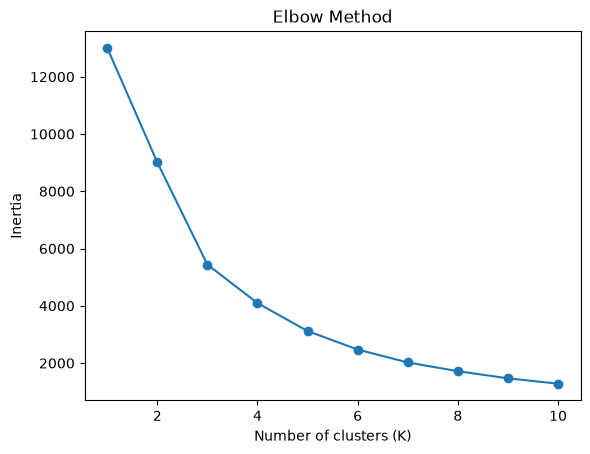

In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Inertia dropped sharply up to K=3 and flattened afterwards, so the optimal number of clusters is 3.

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# add cluster labels back to the RFM table
rfm['Cluster'] = kmeans.labels_

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


K-Means was applied with K=3 on the standardised RFM data. Each customer was assigned to one of three clusters, and the labels were added to the RFM table.

## Visualise clusters using scatter plots

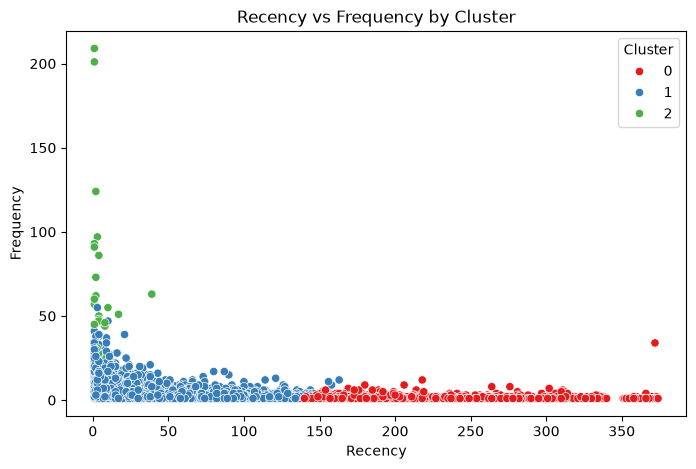

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set1')
plt.title('Recency vs Frequency by Cluster')
plt.show()

**Recency vs Frequency:** Cluster 2 has very recent and very frequent buyers, cluster 1 has recent buyers with moderate frequency, and cluster 0 has customers who have not purchased for a long time.

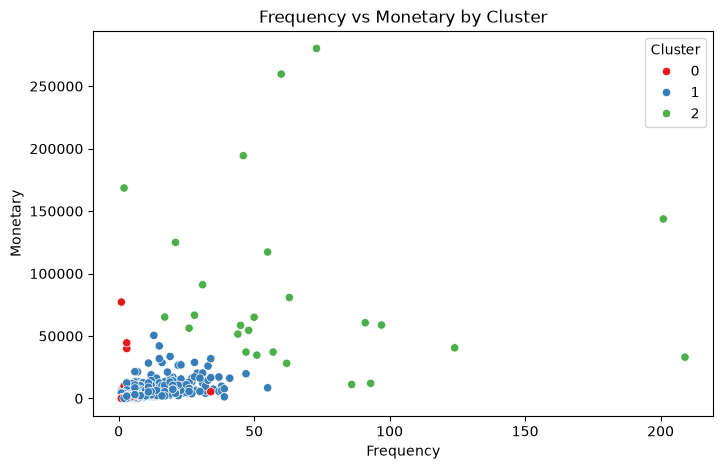

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1')
plt.title('Frequency vs Monetary by Cluster')
plt.show()

**Frequency vs Monetary:** Cluster 2 customers place many orders and spend far more than the others. Clusters 0 and 1 are concentrated at low spend and low frequency.

## Cluster profiling

In [24]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,247.106285,1.582255,629.663689
1,41.454180,4.672755,1849.670202
2,6.038462,66.423077,85826.078077


Cluster 0 (Inactive / Lost) has high recency, low frequency and low spend, so these customers have not purchased for a long time. Cluster 1 (Regular / Active) has moderate values for all three features and forms the main customer base. Cluster 2 (VIP / Champions) has very low recency, very high frequency and very high spend, so these are the most valuable customers.

## Bar chart: number of customers per cluster

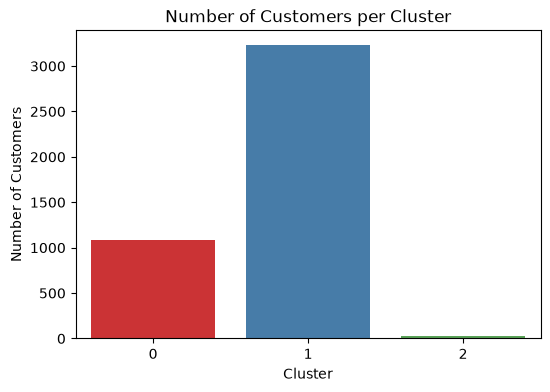

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=rfm, x='Cluster', hue='Cluster', palette='Set1', legend=False)
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

**Customers per Cluster:** The Regular cluster 1 has the most customers, followed by the Inactive cluster 0. The VIP cluster 2 is very small, but each one spends far more than the rest, so this group is the most valuable.

## Insights and Marketing Recommendations

**Cluster 2: VIP / Champions**
- Profile: bought very recently, order very often, spend the most. Very few customers, but the highest value.
- Action: loyalty rewards, early access to new products, exclusive offers and a dedicated account manager or personal thank-you. The goal is to keep them, since losing even one is costly.

**Cluster 1: Regular / Active**
- Profile: bought fairly recently, moderate orders and moderate spend. This is the largest group.
- Action: upselling and cross-selling (suggest related products), bundle deals, and reward points to encourage more frequent purchases. The goal is to move them towards VIP.

**Cluster 0: Inactive / Lost**
- Profile: have not bought for a long time, very few orders, low spend.
- Action: win-back emails ("we miss you"), discount coupons or free delivery offers, and a short feedback survey to learn why they left. Avoid heavy spending on them, since many may not return.